# 14 — Event study per individueel aandeel (Prioriteit-1 vervolgpiste)

**Hypothese**: brede indices (SPY/SPX) middelen bedrijfsspecifieke effecten weg.
Als Trump expliciet een bedrijf noemt — "Boeing", "Apple", "Tesla" — verwachten we
een grotere koersreactie op *dat aandeel* dan op de brede markt. Dit is een
specifiekere en methodologisch sterkere hypothese dan het index-niveau (nb10/nb11).

**Aanpak** (spiegelt nb10/nb11, maar per bedrijf):
1. Extraheer bedrijfsvermeldingen uit alle 26.819 posts via een curated
   bedrijf→ticker mapping (`src/features/company_mentions.py`).
2. Download daily koersen per genoemd bedrijf + benchmark (SPY) + sector-ETF.
3. Bereken **market-model abnormal returns**: regresseer aandeelrendement op SPY
   over een estimation window, AR = werkelijk − verwacht. Dit isoleert het
   bedrijfsspecifieke effect van de algemene marktbeweging.
4. Event-study: vergelijk AR_1d en CAR_3d op **mention-dagen** vs. **controle-dagen**
   (zelfde aandeel, dagen zonder Trump-vermelding). Welch t-toets + Bonferroni.
5. Top-movers en interpretatie.

> **Let op**: yfinance vereist internettoegang. Draai deze notebook lokaal.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

from src.features.company_mentions import (
    tag_posts, mention_counts, explode_mentions, COMPANIES,
)

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ESTIMATION_WINDOW = 120   # handelsdagen voor market-model schatting
ESTIMATION_GAP = 11       # gap-dagen tussen estimation en event (vermijd leakage)
MIN_POSTS = 30            # minimaal aantal mention-dagen om een bedrijf te bestuderen
print("Setup klaar.")


Setup klaar.


## 1. Posts laden en bedrijven taggen

We gebruiken het volledige Kaggle-archief (feb 2022 – apr 2026, 26.819 posts).
Dit geeft een veel grotere steekproef dan de intraday Iran-analyse (nb10).

In [2]:
posts = pd.read_parquet("../data/raw/posts.parquet")
posts["timestamp_utc"] = pd.to_datetime(posts["timestamp_utc"], utc=True)
posts["post_id"] = posts["post_id"].astype(str)

tagged = tag_posts(posts)
counts = mention_counts(tagged)

print(f"Totaal posts: {len(posts):,}")
print(f"Posts met >=1 bedrijf: {(tagged['n_companies'] > 0).sum():,}")
print()
counts


Totaal posts: 26,819
Posts met >=1 bedrijf: 1,273



,ticker,company,sector_etf,n_posts
0,DJT,Truth Social,XLC,573
1,TWTR,Twitter,XLC,206
2,GOOGL,Google,XLC,173
3,META,Meta,XLC,106
4,TSLA,Tesla,XLY,94
5,AMZN,Amazon,XLY,66
6,AAPL,Apple,XLK,49
7,BA,Boeing,ITA,18
8,DIS,Disney,XLC,13
9,MCD,McDonald's,XLY,11


## 2. Verhandelbaarheids-caveats

Niet elke vermelding is bruikbaar als event:

- **DJT (Trump Media)**: pas beursgenoteerd vanaf **2024-03-26** (SPAC-merger). Posts
  daarvóór die "Truth Social" noemen, kunnen geen koerseffect hebben — die filteren
  we weg.
- **TWTR (Twitter)**: van de beurs gehaald op **2022-10-27** (overname Musk). Alleen
  vermeldingen vóór die datum zijn verhandelbaar.
- Bedrijven met te weinig mention-dagen (`< MIN_POSTS`) hebben onvoldoende power
  voor een t-toets en worden alleen beschrijvend getoond.

In [3]:
# Verhandelbaarheids-windows (None = volledige history)
TRADEABLE_WINDOW = {
    "DJT": (pd.Timestamp("2024-03-26", tz="UTC"), None),
    "TWTR": (None, pd.Timestamp("2022-10-27", tz="UTC")),
}

exploded = explode_mentions(tagged)

def in_tradeable_window(row):
    start, end = TRADEABLE_WINDOW.get(row["ticker"], (None, None))
    ts = row["timestamp_utc"]
    if start is not None and ts < start:
        return False
    if end is not None and ts > end:
        return False
    return True

exploded = exploded[exploded.apply(in_tradeable_window, axis=1)].copy()

tradeable_counts = (
    exploded.groupby(["ticker", "company", "sector_etf"]).size()
    .reset_index(name="n_posts").sort_values("n_posts", ascending=False)
)
study_tickers = tradeable_counts[tradeable_counts["n_posts"] >= MIN_POSTS]["ticker"].tolist()
print("Bedrijven met genoeg mention-dagen voor toetsing (n >= %d):" % MIN_POSTS)
print(study_tickers)
tradeable_counts


Bedrijven met genoeg mention-dagen voor toetsing (n >= 30):
['DJT', 'GOOGL', 'META', 'TSLA', 'AMZN', 'AAPL', 'TWTR']


,ticker,company,sector_etf,n_posts
4,DJT,Truth Social,XLC,491
7,GOOGL,Google,XLC,173
14,META,Meta,XLC,106
19,TSLA,Tesla,XLY,94
1,AMZN,Amazon,XLY,66
0,AAPL,Apple,XLK,49
20,TWTR,Twitter,XLC,36
2,BA,Boeing,ITA,18
3,DIS,Disney,XLC,13
13,MCD,McDonald's,XLY,11


## 3. Marktdata downloaden

Per studie-ticker downloaden we daily OHLCV over de volledige history, plus de
benchmark **SPY** en alle benodigde sector-ETF's.

In [4]:
def download_daily(symbol, start="2022-02-01"):
    df = yf.download(symbol, start=start, interval="1d", progress=False, auto_adjust=True)
    if df.empty:
        return None
    if df.columns.nlevels > 1:
        df.columns = [c.lower() for c in df.columns.get_level_values(0)]
    else:
        df.columns = [c.lower() for c in df.columns]
    df = df.reset_index().rename(columns={"Date": "date", "index": "date"})
    df.columns = [c.lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.normalize()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df[["date", "close", "volume", "log_return"]]

# Verzamel alle symbolen: studie-tickers + hun sector-ETF's + SPY benchmark
sector_etfs = sorted({c.sector_etf for c in COMPANIES if c.ticker in study_tickers})
symbols = sorted(set(study_tickers) | set(sector_etfs) | {"SPY"})
print("Downloaden:", symbols)

prices = {}
for sym in symbols:
    d = download_daily(sym)
    if d is not None:
        prices[sym] = d
        print(f"  {sym}: {len(d)} dagen ({d['date'].min().date()} -> {d['date'].max().date()})")
    else:
        print(f"  {sym}: GEEN data")


Downloaden: ['AAPL', 'AMZN', 'DJT', 'GOOGL', 'META', 'SPY', 'TSLA', 'TWTR', 'XLC', 'XLK', 'XLY']
  AAPL: 1094 dagen (2022-02-01 -> 2026-06-11)
  AMZN: 1094 dagen (2022-02-01 -> 2026-06-11)
  DJT: 1094 dagen (2022-02-01 -> 2026-06-11)
  GOOGL: 1094 dagen (2022-02-01 -> 2026-06-11)
  META: 1094 dagen (2022-02-01 -> 2026-06-11)
  SPY: 1094 dagen (2022-02-01 -> 2026-06-11)
  TSLA: 1094 dagen (2022-02-01 -> 2026-06-11)


$TWTR: possibly delisted; no timezone found

1 Failed download:
['TWTR']: possibly delisted; no timezone found


  TWTR: GEEN data
  XLC: 1094 dagen (2022-02-01 -> 2026-06-11)
  XLK: 1094 dagen (2022-02-01 -> 2026-06-11)
  XLY: 1094 dagen (2022-02-01 -> 2026-06-11)


## 4. Market-model abnormal returns

Voor elk aandeel schatten we per event-dag het *verwachte* rendement met een
market-model regressie op SPY over het estimation window
`[t-ESTIMATION_WINDOW-GAP, t-GAP]` (gap voorkomt dat het event zelf de schatting
beïnvloedt):

$$r_{i,t} = \alpha_i + \beta_i \, r_{SPY,t} + \varepsilon_{i,t}, \quad
AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i \, r_{SPY,t})$$

De AR is per definitie al markt-gecorrigeerd, dus het *bedrijfsspecifieke* effect.

In [5]:
def compute_market_model_ar(stock_df, market_df,
                             est_window=ESTIMATION_WINDOW, gap=ESTIMATION_GAP):
    """Voeg market-model abnormal return per dag toe aan stock_df."""
    m = stock_df.merge(
        market_df[["date", "log_return"]].rename(columns={"log_return": "mkt_ret"}),
        on="date", how="left",
    ).sort_values("date").reset_index(drop=True)
    ar = np.full(len(m), np.nan)
    for i in range(len(m)):
        lo, hi = i - gap - est_window, i - gap
        if lo < 0:
            continue
        est = m.iloc[lo:hi][["log_return", "mkt_ret"]].dropna()
        if len(est) < est_window * 0.6:
            continue
        beta, alpha = np.polyfit(est["mkt_ret"], est["log_return"], 1)
        expected = alpha + beta * m.loc[i, "mkt_ret"]
        ar[i] = m.loc[i, "log_return"] - expected
    m["ar"] = ar
    # CAR over [t, t+2] (3 handelsdagen)
    m["car_3d"] = m["ar"] + m["ar"].shift(-1) + m["ar"].shift(-2)
    return m

spy = prices["SPY"]
ar_tables = {}
for tkr in study_tickers:
    if tkr in prices:
        ar_tables[tkr] = compute_market_model_ar(prices[tkr], spy)
        n_valid = ar_tables[tkr]["ar"].notna().sum()
        print(f"{tkr}: {n_valid} dagen met geldige AR")


DJT: 963 dagen met geldige AR
GOOGL: 963 dagen met geldige AR
META: 963 dagen met geldige AR
TSLA: 963 dagen met geldige AR
AMZN: 963 dagen met geldige AR
AAPL: 963 dagen met geldige AR


## 5. Event-study per bedrijf

Voor elk bedrijf koppelen we elke mention-post aan de eerstvolgende handelsdag
(post in het weekend → maandag). De **mention-dagen** vergelijken we met de
**controle-dagen** van hetzelfde aandeel (alle handelsdagen zonder vermelding).
Welch t-toets op AR_1d en CAR_3d.

In [6]:
def align_posts_to_trading_day(post_times, trading_dates):
    """Map elke post naar de eerstvolgende handelsdag (>= post-datum)."""
    td = pd.Series(sorted(trading_dates))
    out = []
    for ts in post_times:
        d = ts.normalize()
        nxt = td[td >= d]
        out.append(nxt.iloc[0] if len(nxt) else pd.NaT)
    return pd.Series(out)

results = []
event_detail = {}
for tkr in study_tickers:
    if tkr not in ar_tables:
        continue
    art = ar_tables[tkr]
    trading_dates = art["date"].tolist()
    post_times = exploded[exploded["ticker"] == tkr]["timestamp_utc"]
    mention_days = set(align_posts_to_trading_day(post_times, trading_dates).dropna())

    art = art.copy()
    art["is_mention"] = art["date"].isin(mention_days)
    valid = art.dropna(subset=["ar"])
    event_detail[tkr] = valid

    for metric in ["ar", "car_3d"]:
        m_vals = valid[valid["is_mention"]][metric].dropna()
        c_vals = valid[~valid["is_mention"]][metric].dropna()
        if len(m_vals) < 10 or len(c_vals) < 10:
            continue
        t_stat, p_val = stats.ttest_ind(m_vals, c_vals, equal_var=False)
        results.append({
            "ticker": tkr,
            "metric": "AR_1d" if metric == "ar" else "CAR_3d",
            "n_mention": len(m_vals),
            "mean_mention_bp": m_vals.mean() * 1e4,
            "mean_control_bp": c_vals.mean() * 1e4,
            "delta_bp": (m_vals.mean() - c_vals.mean()) * 1e4,
            "t_stat": t_stat,
            "p_value": p_val,
        })

res = pd.DataFrame(results).sort_values("p_value")
res


,ticker,metric,n_mention,mean_mention_bp,mean_control_bp,delta_bp,t_stat,p_value
1,DJT,CAR_3d,217,-117.974228,40.397829,-158.372057,-2.092319,0.037041
6,TSLA,AR_1d,52,-110.281768,4.984493,-115.266261,-2.027920,0.047484
7,TSLA,CAR_3d,52,-169.639256,6.079599,-175.718856,-1.813820,0.075183
9,AMZN,CAR_3d,50,46.329703,-5.014707,51.344410,1.545456,0.127745
3,GOOGL,CAR_3d,127,-30.669284,7.924210,-38.593494,-1.356730,0.176772
8,AMZN,AR_1d,50,19.760039,-2.037054,21.797093,0.978293,0.332263
5,META,CAR_3d,79,26.337382,-4.922944,31.260326,0.819507,0.414430
2,GOOGL,AR_1d,127,-6.059666,1.732140,-7.791806,-0.534285,0.593853
4,META,AR_1d,79,-9.889464,0.027049,-9.916513,-0.497033,0.620218
0,DJT,AR_1d,217,-9.970397,5.080423,-15.050820,-0.357482,0.720906


## 6. Multiple-testing correctie

We toetsen meerdere bedrijven × 2 metrieken. Bonferroni-drempel = 0,05 / aantal
toetsen. Alleen resultaten onder die drempel zijn robuust significant.

In [7]:
n_tests = len(res)
bonf = 0.05 / max(n_tests, 1)
res = res.copy()
res["sig_raw"] = res["p_value"] < 0.05
res["sig_bonferroni"] = res["p_value"] < bonf
print(f"Aantal toetsen: {n_tests} | Bonferroni-drempel: {bonf:.4f}")
print(f"Significant (raw p<0.05): {res['sig_raw'].sum()}")
print(f"Significant (Bonferroni): {res['sig_bonferroni'].sum()}")
res


Aantal toetsen: 12 | Bonferroni-drempel: 0.0042
Significant (raw p<0.05): 2
Significant (Bonferroni): 0


,ticker,metric,n_mention,mean_mention_bp,mean_control_bp,delta_bp,t_stat,p_value,sig_raw,sig_bonferroni
1,DJT,CAR_3d,217,-117.974228,40.397829,-158.372057,-2.092319,0.037041,True,False
6,TSLA,AR_1d,52,-110.281768,4.984493,-115.266261,-2.027920,0.047484,True,False
7,TSLA,CAR_3d,52,-169.639256,6.079599,-175.718856,-1.813820,0.075183,False,False
9,AMZN,CAR_3d,50,46.329703,-5.014707,51.344410,1.545456,0.127745,False,False
3,GOOGL,CAR_3d,127,-30.669284,7.924210,-38.593494,-1.356730,0.176772,False,False
8,AMZN,AR_1d,50,19.760039,-2.037054,21.797093,0.978293,0.332263,False,False
5,META,CAR_3d,79,26.337382,-4.922944,31.260326,0.819507,0.414430,False,False
2,GOOGL,AR_1d,127,-6.059666,1.732140,-7.791806,-0.534285,0.593853,False,False
4,META,AR_1d,79,-9.889464,0.027049,-9.916513,-0.497033,0.620218,False,False
0,DJT,AR_1d,217,-9.970397,5.080423,-15.050820,-0.357482,0.720906,False,False


## 7. Top-movers: individuele mention-dagen met grootste bedrijfsspecifieke beweging

In [8]:
top_rows = []
for tkr, valid in event_detail.items():
    sub = valid[valid["is_mention"]].copy()
    sub["abs_ar"] = sub["ar"].abs()
    sub["ticker"] = tkr
    top_rows.append(sub.nlargest(3, "abs_ar")[["ticker", "date", "ar", "car_3d"]])

top = pd.concat(top_rows).sort_values("ar", key=lambda s: s.abs(), ascending=False)
top["ar_bp"] = top["ar"] * 1e4
top["car_3d_bp"] = top["car_3d"] * 1e4
top[["ticker", "date", "ar_bp", "car_3d_bp"]].head(15)


,ticker,date,ar_bp,car_3d_bp
614,DJT,2024-07-15 00:00:00+00:00,2649.433461,1560.343525
552,DJT,2024-04-15 00:00:00+00:00,-1999.230988,-2155.378145
600,DJT,2024-06-24 00:00:00+00:00,1883.500807,3279.169894
838,TSLA,2025-06-05 00:00:00+00:00,-1430.956903,-869.621635
777,TSLA,2025-03-10 00:00:00+00:00,-963.690845,177.670651
217,TSLA,2022-12-12 00:00:00+00:00,-845.353900,-1504.939618
755,GOOGL,2025-02-05 00:00:00+00:00,-806.851927,-1065.121919
256,GOOGL,2023-02-08 00:00:00+00:00,-645.670594,-1029.418602
799,AAPL,2025-04-09 00:00:00+00:00,573.443766,778.802809
188,META,2022-10-31 00:00:00+00:00,-501.891978,-284.696618


## 8. Visualisatie: gemiddelde AR per bedrijf (mention vs. controle)

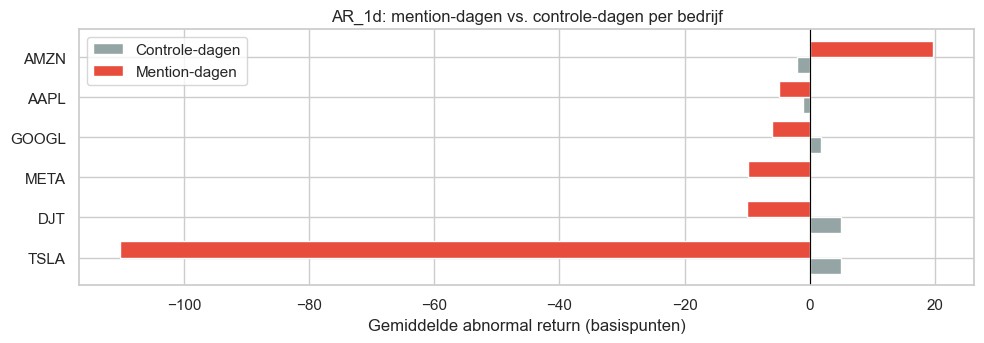

In [9]:
ar_res = res[res["metric"] == "AR_1d"].sort_values("delta_bp")
if len(ar_res):
    fig, ax = plt.subplots(figsize=(10, max(3, 0.6 * len(ar_res))))
    y = np.arange(len(ar_res))
    ax.barh(y - 0.2, ar_res["mean_control_bp"], height=0.4, label="Controle-dagen", color="#95a5a6")
    ax.barh(y + 0.2, ar_res["mean_mention_bp"], height=0.4, label="Mention-dagen", color="#e74c3c")
    ax.set_yticks(y)
    ax.set_yticklabels(ar_res["ticker"])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Gemiddelde abnormal return (basispunten)")
    ax.set_title("AR_1d: mention-dagen vs. controle-dagen per bedrijf")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../reports/figures/nb14_ar_per_company.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("Geen resultaten om te plotten.")


## 9. Bevindingen & scriptie-verhaal

**Vul aan met je echte resultaten na het draaien:**

1. **Welke bedrijven** vertonen een significant verschil tussen mention- en
   controle-dagen (AR_1d en/of CAR_3d)? Houdt dit stand na Bonferroni?
2. **Richting** van het effect: positief (Trump prijst het bedrijf) of negatief
   (Trump valt het aan)? Vergelijk met de toon/sentiment van de posts.
3. **Vergelijking met index-niveau** (nb10/nb11): is het bedrijfsspecifieke effect
   inderdaad groter dan op SPY/SPX? Dit is de kern van de hypothese.
4. **Caveats**: kleine steekproef per bedrijf, mention ≠ causaliteit (common-cause
   blijft mogelijk — vgl. GDELT nb13), en sommige mentions zijn niet markt-relevant
   (Trump noemt "Truth Social" promotioneel, niet als beleggings-signaal).

**Mogelijke vervolgstap**: koppel per mention-dag de GDELT news-timing (nb13) om te
toetsen of het bedrijfseffect groter is bij *niet-reactieve* posts.
